# 12 — The lesion story: how EAE lesions form, resolve or persist, and what the stains show

A picture-led summary of notebooks 10 and 11 (all five RRMAP2 runs, 67 animals, 1.38 M cells; images for all
runs). Every claim comes with the plot behind it **and** with the tissue: whole-piece maps, microscopy overviews
and single-cell galleries. Statistics are per animal; groups are small, so the evidence is consistency across
independent contrasts, stated with each finding.

1. The two disease courses (clinical scores)
2. Lesions redefined against controls, and the six lesion states
3. Lesion states in the tissue, along both courses
4. **Vimentin marks lesions that are being contained** (the stains' clearest contribution)
5. Chronic severity = lesions that stayed active
6. Relapse and B cells
7. Chronic vs relapsing-remitting at the same peak
8. Damage memory: neuropil returns, vimentin builds
9. Caveats and what's next

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from skimage.segmentation import find_boundaries

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/12_lesion_story.ipynb"
OUT = ROOT / "results" / "12_lesion_story"
OUT.mkdir(parents=True, exist_ok=True)
RES = ROOT / "results"
PX = 0.2125
COL = plotting.CATEGORICAL
cfg = data.load_config()
bundles = find_bundles(cfg)
_open = {}


def bundle(sec):
    if sec not in _open:
        _open[sec] = XeniumBundle(bundles[sec])
    return _open[sec]


def show(path, width=1100):
    display(Image(filename=str(RES / path), width=width))

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "x_centroid", "y_centroid",
             "Anno_L1_curated", "Global_anatomical_region"]].copy()
a.file.close()
obs["stage"] = obs.stage.astype(str)
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet"))
animals = pd.read_csv(RES / "11_disease_courses" / "animal_table.csv", index_col=0)
STATES = sorted(s for s in obs.lesion_state.unique() if s.startswith("S"))
SHORT = {s: s.split(":")[0] for s in STATES}
STATE_COL = {"no lesion": "#e3e3e3", "not scored": "#ffffff"}
# active (monocyte-derived) = warm, late/fibrotic = green, glial = blue, other = yellow/pink
PAL = {"S0": COL[0], "S1": COL[1], "S2": COL[2], "S3": COL[3], "S4": COL[4], "S5": COL[6]}
STATE_COL.update({s: PAL[SHORT[s]] for s in STATES})
print(len(animals), "animals |", ", ".join(STATES))

67 animals | S0: astro reactivity + oligo disease state, S1: monocyte-derived myeloid + microglia homeostasis loss, S2: fibrosis + myelinating oligo loss, S3: astro reactivity + MHC-II / IFN, S4: monocyte-derived myeloid + oligo disease state, S5: infiltration + microglia homeostasis loss


## 1. Two disease courses
Daily clinical scores of every animal in the dataset, coloured by the stage at which it was taken for Xenium
(data: `data/clinical/`). **Chronic** (MOG35–55): one attack, then mild or severe chronic disease. **Relapsing–
remitting** (PLP139–151): attack, remission, relapses; MONOPHASIC animals never relapsed.

/tmp/ipykernel_35352/1710868361.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(x[ok][-1], y[ok][-1], color=c, s=14, zorder=3)
/tmp/ipykernel_35352/1710868361.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(x[ok][-1], y[ok][-1], color=c, s=14, zorder=3)
/tmp/ipykernel_35352/1710868361.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(x[ok][-1], y[ok][-1], color=c, s=14, zorder=3)
/tmp/ip

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/clinical_courses.png')

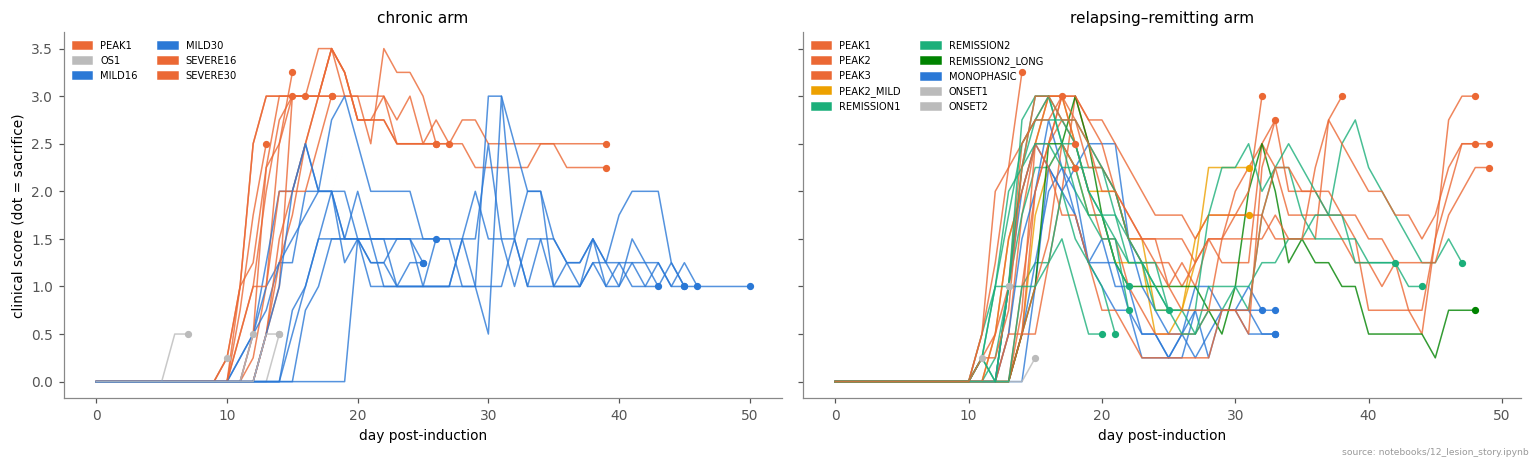

In [3]:
sc = pd.read_excel(ROOT / "data" / "clinical" / "Fixed_RRMap2_FinalSamples_AllScore_curated_20260723_212152.xlsx")
sc = sc.drop_duplicates("sample_name").set_index("sample_name")
sc = sc.rename(index={f"C_M30_{k}": f"C_L_{k}" for k in range(1, 6)})  # MILD30 names (scripts/clinical_metrics.py)
sc = sc[sc.index.isin(animals.index)]
days = [c for c in sc.columns if c.startswith("d") and c[1:].isdigit()]
STG_COL = {"PEAK1": COL[1], "PEAK2": COL[1], "PEAK3": COL[1], "PEAK2_MILD": COL[3], "REMISSION1": COL[2],
           "REMISSION2": COL[2], "REMISSION2_LONG": COL[5], "MONOPHASIC": COL[0], "ONSET1": "#bbbbbb",
           "ONSET2": "#bbbbbb", "OS1": "#bbbbbb", "MILD16": COL[0], "MILD30": COL[0], "SEVERE16": COL[1],
           "SEVERE30": COL[1]}
fig, axs = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for ax, (arm, title) in zip(axs, [("CHRONIC", "chronic arm"), ("RELAPSE REMITTING", "relapsing–remitting arm")]):
    d = sc[sc.model == arm]
    for an, r in d.iterrows():
        y = pd.to_numeric(r[days], errors="coerce")
        x = np.array([int(c[1:]) for c in days])
        ok = y.notna().to_numpy()
        if y.max() == 0:
            continue
        c = STG_COL.get(r.stage, "#bbbbbb")
        ax.plot(x[ok], y[ok], color=c, lw=1, alpha=0.8)
        ax.scatter(x[ok][-1], y[ok][-1], color=c, s=14, zorder=3)
    hand = [Patch(color=c, label=s) for s, c in STG_COL.items() if s in set(d.stage)]
    ax.legend(handles=hand, fontsize=6.5, ncol=2, loc="upper left")
    ax.set(title=title, xlabel="day post-induction")
axs[0].set_ylabel("clinical score (dot = sacrifice)")
fig.tight_layout()
plotting.save_fig(fig, "clinical_courses", OUT, SRC)

> Chronic **severe** animals all peaked at 3.5 and never came below 2.25; **mild** ones peaked at 1.5–2.5 and
> partly recovered. In the RR arm, the first attack looks the same in animals that later relapse and in those that
> don't (monophasic first peaks 2.25–2.75 vs relapsers 2.5–3.0). The clinical course alone can't tell who will
> relapse.

## 2. Lesions redefined, and six lesion states
The curated niche labels called 4–20 % of never-immunised control tissue "lesion". Here a lesion is a 30-cell
neighbourhood outside what control animals of the same region (WM / GM / meninges) show, calibrated so held-out
controls are ~1 % lesion (notebook 10). Old (grey) vs new (coloured) lesion share per animal:

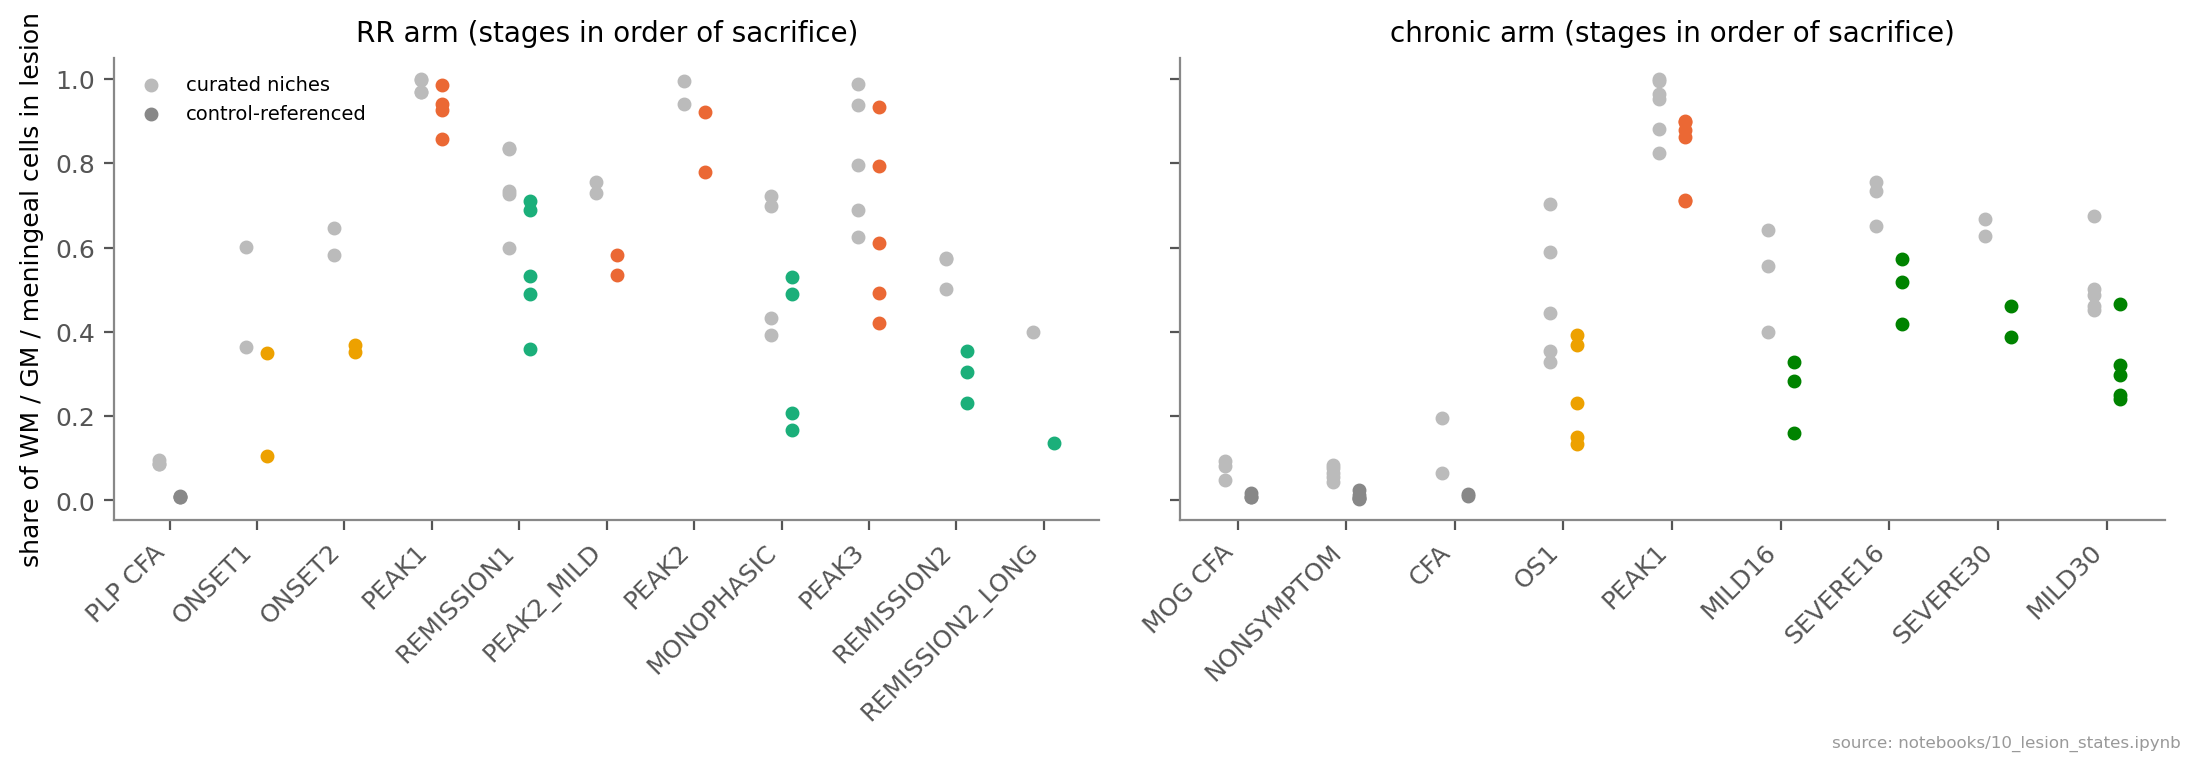

In [4]:
show("10_lesion_states/lesion_share_old_vs_new.png")

Lesion neighbourhoods fall into six states, named after the axes that distinguish them (z against control
neighbourhoods; notebook 10):

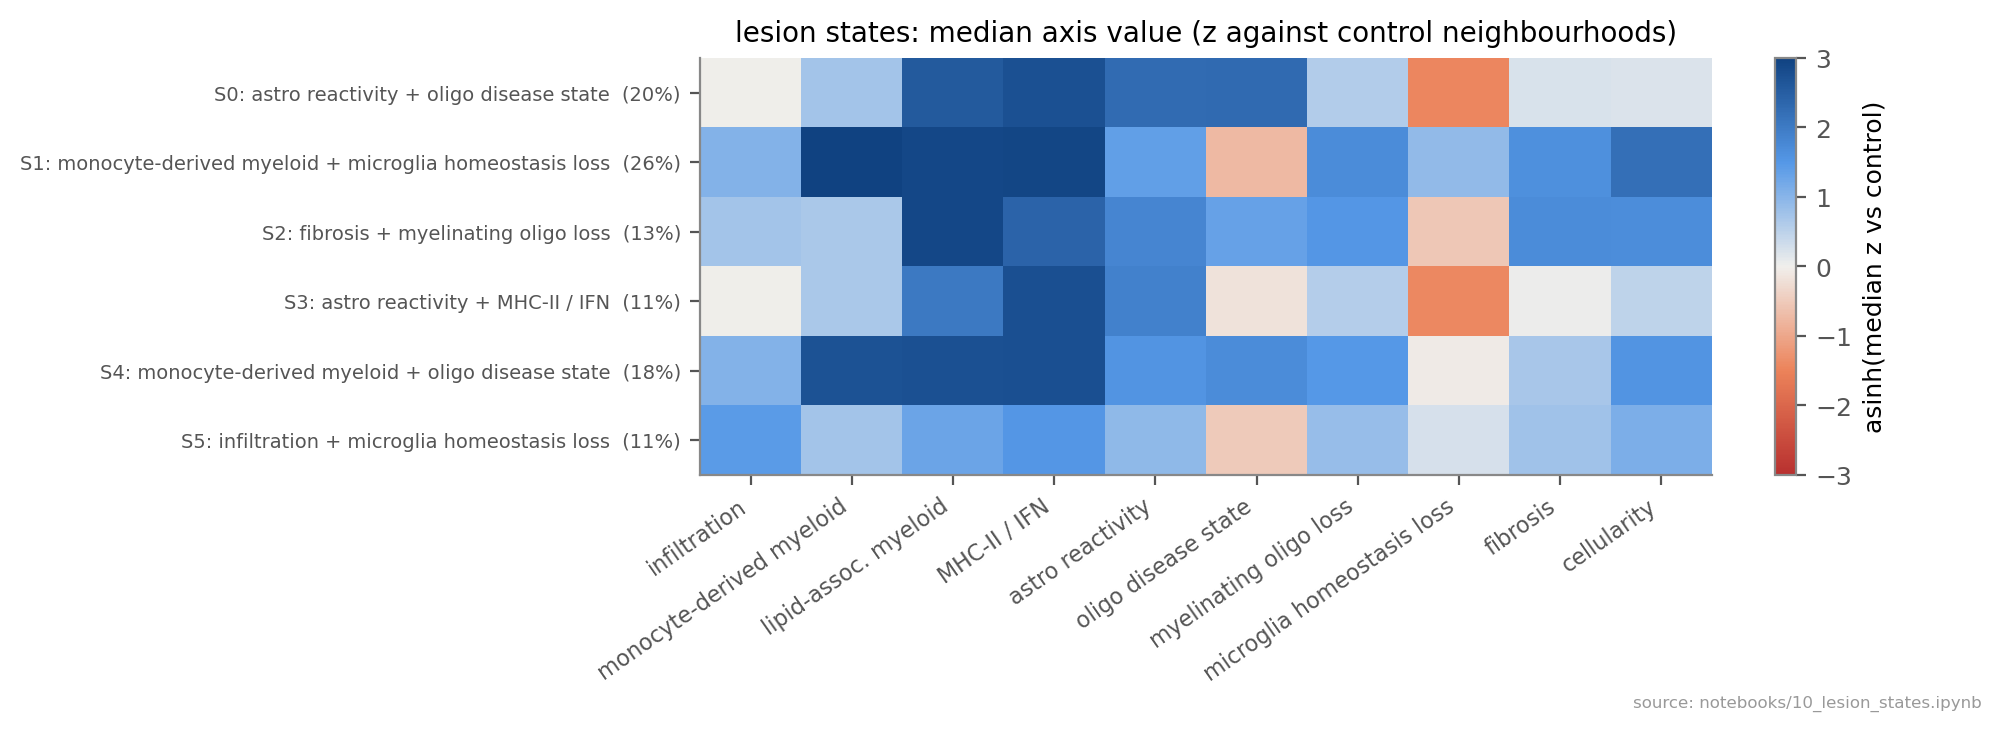

In [5]:
show("10_lesion_states/lesion_state_profiles.png", 950)

Read as biology: **S1** and **S4** are *active* lesions (monocyte-derived macrophages, dense, myelin and
oligodendrocyte damage); **S2** is the *late, fibrotic, demyelinated* lesion (lipid-laden myeloid cells, ECM, few
infiltrating cells); **S0** and **S3** are *glial-reactive* tissue (reactive astrocytes, disease-associated
oligodendrocytes, MHC-II); **S5** is lymphocytic infiltrate.

## 3. Lesion states in the tissue
One representative animal per stage: the animal with the median lesion share of its stage, and its largest tissue
piece (not chosen by eye). Grey = no lesion.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/lesion_state_maps.png')

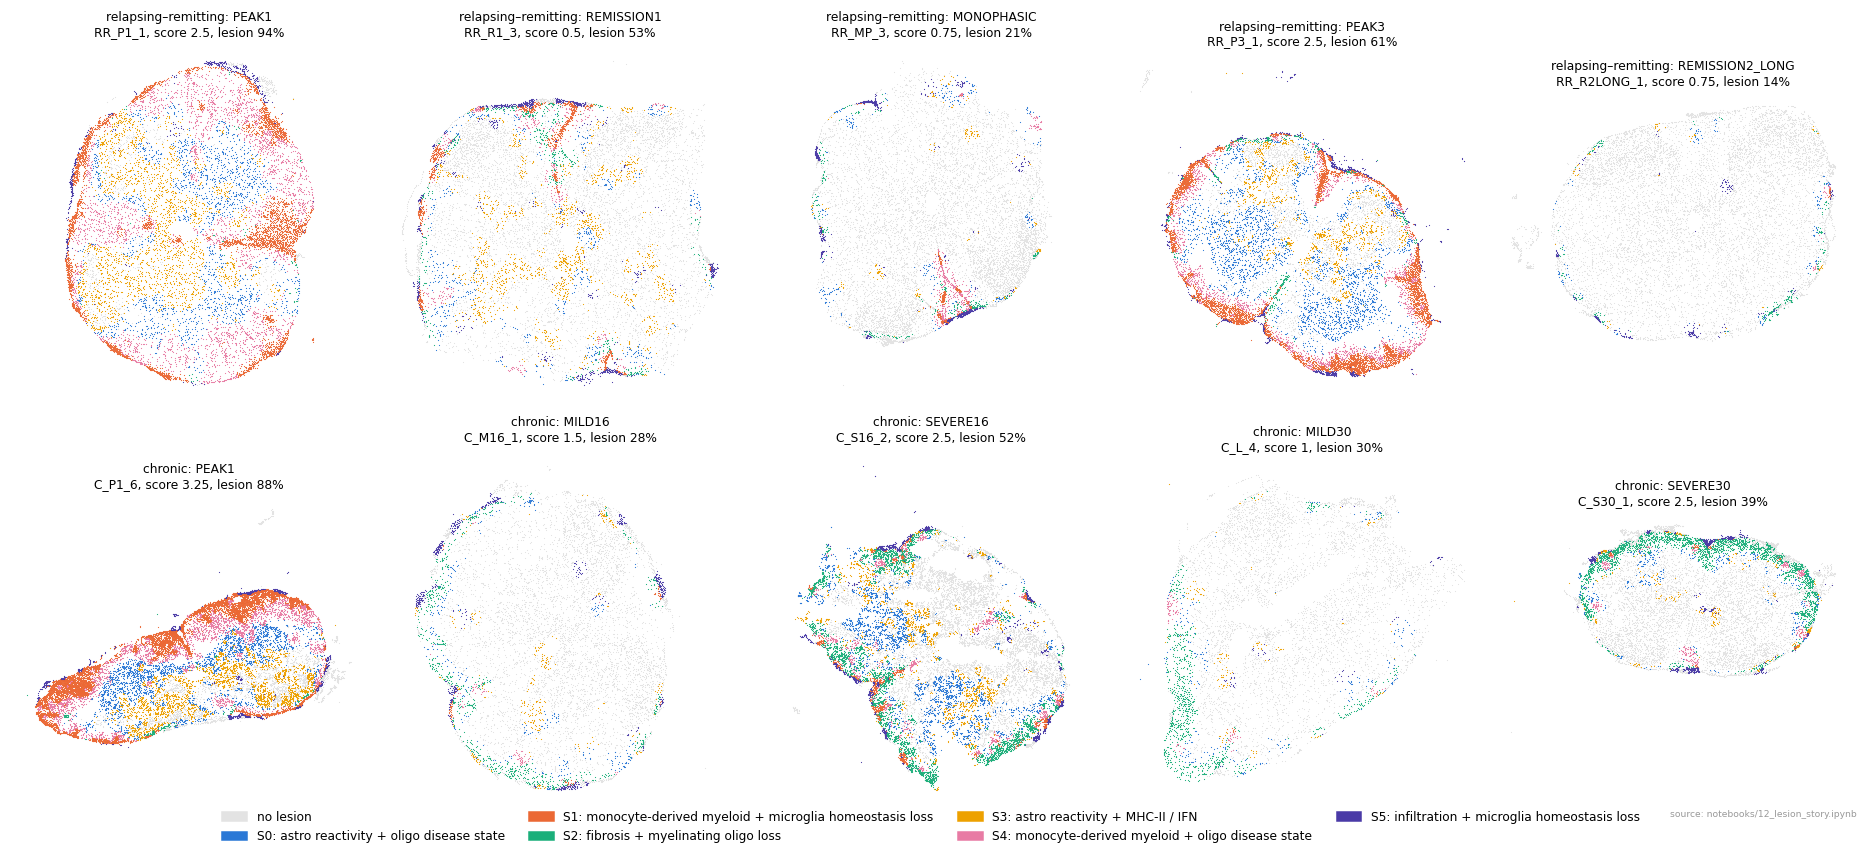

In [6]:
def piece_of(animal):
    g = obs[obs.sample_name == animal]
    return g.meta_sample_id.value_counts().index[0]


def state_map(ax, piece, title, s=0.6):
    g = obs[obs.meta_sample_id == piece]
    for st in ["no lesion"] + STATES:
        m = g.lesion_state == st
        ax.scatter(g.x_centroid[m], -g.y_centroid[m], s=s, color=STATE_COL[st], rasterized=True, lw=0)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=8)


rows = [("relapsing–remitting", ["PEAK1", "REMISSION1", "MONOPHASIC", "PEAK3", "REMISSION2_LONG"]),
        ("chronic", ["PEAK1", "MILD16", "SEVERE16", "MILD30", "SEVERE30"])]
fig, axs = plt.subplots(2, 5, figsize=(17, 7.5))
for r, (arm, stages) in enumerate(rows):
    sub = animals[animals.arm == ("RR" if r == 0 else "chronic")]
    for ax, stg in zip(axs[r], stages):
        d = sub[sub.stage == stg]["lesion share"].dropna()
        an = (d - d.median()).abs().idxmin()
        state_map(ax, piece_of(an), f"{arm}: {stg}\n{an}, score {animals.loc[an, 'score']:g}, "
                                    f"lesion {animals.loc[an, 'lesion share']:.0%}")
fig.legend(handles=[Patch(color=STATE_COL[s], label=s) for s in ["no lesion"] + STATES], loc="lower center",
           ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout()
plotting.save_fig(fig, "lesion_state_maps", OUT, SRC)

> At the first peak, active monocyte-derived lesion (orange/pink, S1/S4) fills most of the white matter. In
> remission and in monophasic animals the active core is largely gone; what stays is late fibrotic tissue (green, S2)
> and glial-reactive rims (blue, S0). Long remission leaves small residues. Chronic severe animals keep active
> tissue at d28–41; mild ones are mostly late/glial.

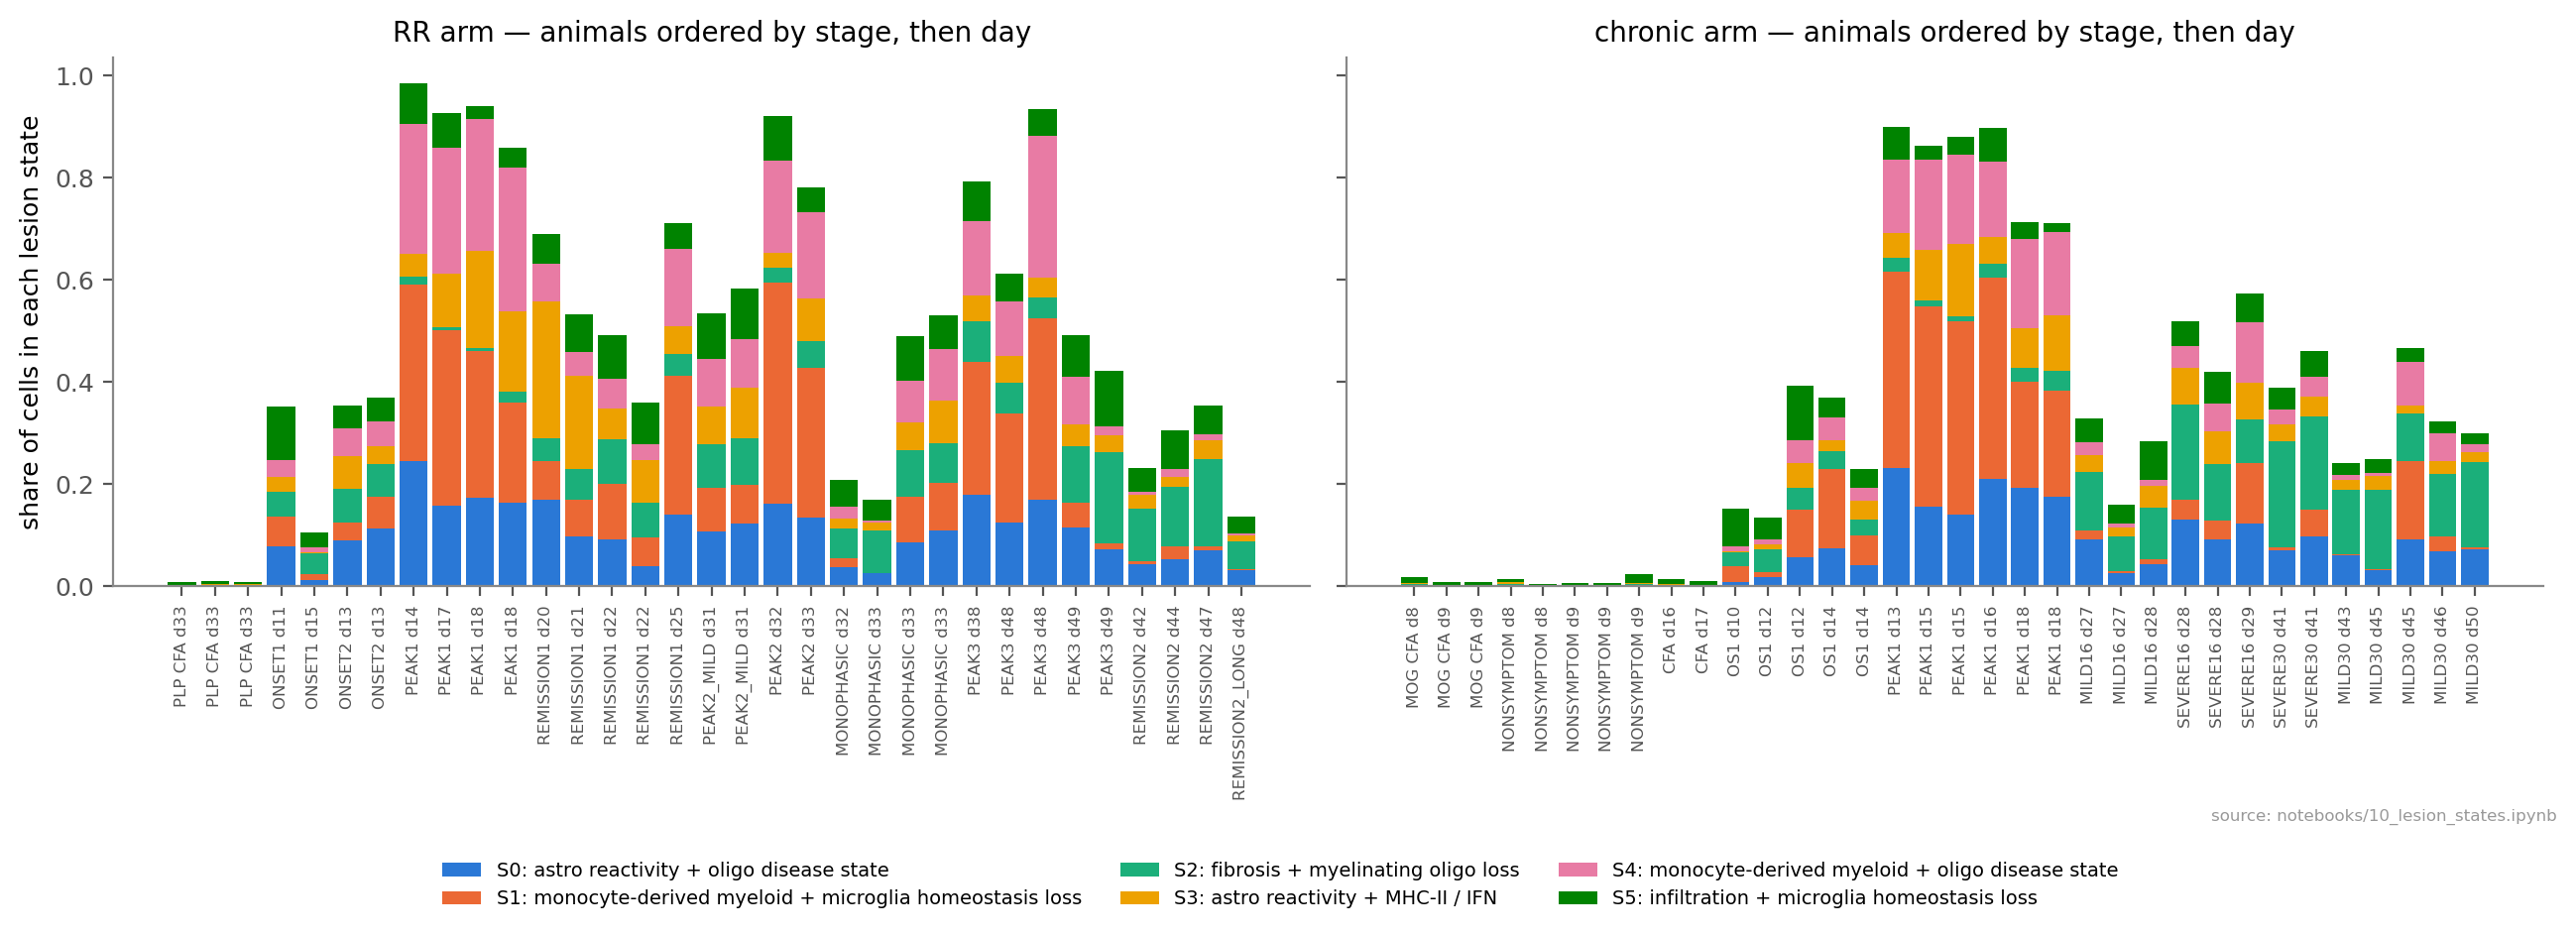

In [7]:
show("10_lesion_states/lesion_state_trajectories.png")

## 4. Vimentin marks lesions that are being contained
*Vim* is not on the 5K panel, so the αSMA/vimentin stain is the only per-cell vimentin readout. In astrocytes it
reports reactive, scar-forming astrocytes. Astrocyte vimentin **inside lesions** (robust z within image) is higher
wherever disease is milder or resolving, in every contrast we have:

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/vimentin_contrasts.png')

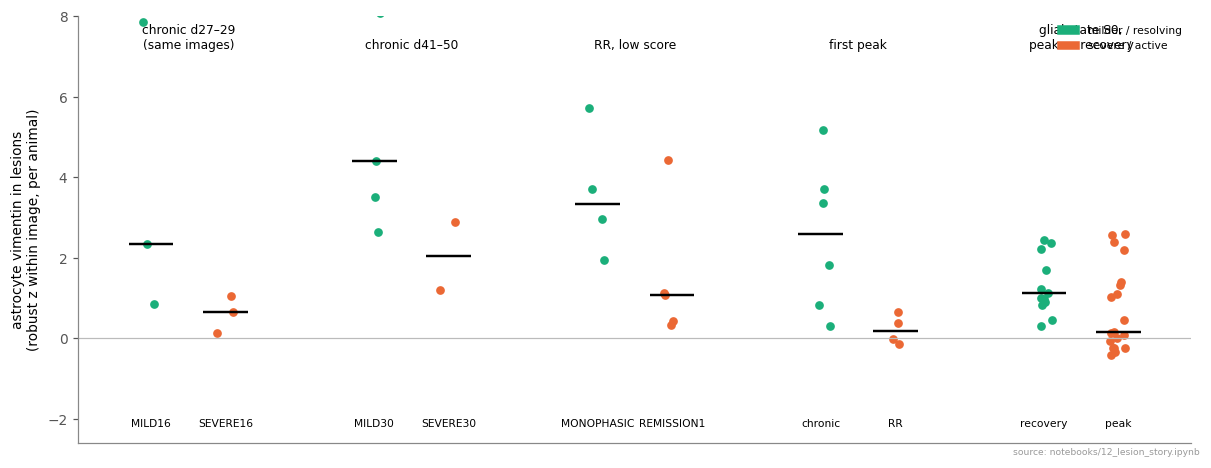

In [8]:
vim = "img lesion: astro vimentin (z)"
pa = pd.read_csv(RES / "11_disease_courses" / "image_readouts_per_animal_state.csv")
s0 = [s for s in STATES if s.startswith("S0")][0]
contrasts = [
    ("chronic d27–29\n(same images)", animals[animals.stage == "MILD16"][vim], animals[animals.stage == "SEVERE16"][vim],
     "MILD16", "SEVERE16"),
    ("chronic d41–50", animals[animals.stage == "MILD30"][vim], animals[animals.stage == "SEVERE30"][vim],
     "MILD30", "SEVERE30"),
    ("RR, low score", animals[animals.stage == "MONOPHASIC"][vim], animals[animals.stage == "REMISSION1"][vim],
     "MONOPHASIC", "REMISSION1"),
    ("first peak", animals[(animals.stage == "PEAK1") & (animals.arm == "chronic")][vim],
     animals[(animals.stage == "PEAK1") & (animals.arm == "RR")][vim], "chronic", "RR"),
    ("glial state S0,\npeak vs recovery", pa[(pa.lesion_state == s0) & (pa.group == "recovery")]["astro vimentin (z)"],
     pa[(pa.lesion_state == s0) & (pa.group == "peak")]["astro vimentin (z)"], "recovery", "peak"),
]
fig, ax = plt.subplots(figsize=(11, 4.2))
rng = np.random.default_rng(0)
for i, (lab, good, bad, lg, lb) in enumerate(contrasts):
    for k, (v, c, l) in enumerate([(good.dropna(), COL[2], lg), (bad.dropna(), COL[1], lb)]):
        xx = 3 * i + k + rng.uniform(-0.12, 0.12, len(v))
        ax.scatter(xx, v, s=22, color=c)
        ax.hlines(v.median(), 3 * i + k - 0.3, 3 * i + k + 0.3, color="black", lw=1.6)
        ax.text(3 * i + k, -2.2, l, ha="center", fontsize=7)
    ax.text(3 * i + 0.5, 7.2, lab, ha="center", fontsize=8)
ax.axhline(0, color="#bbbbbb", lw=0.8)
ax.set_xticks([]); ax.set_ylim(-2.6, 8)
ax.set_ylabel("astrocyte vimentin in lesions\n(robust z within image, per animal)")
ax.legend(handles=[Patch(color=COL[2], label="milder / resolving"), Patch(color=COL[1], label="severe / active")],
          fontsize=7, loc="upper right")
fig.tight_layout()
plotting.save_fig(fig, "vimentin_contrasts", OUT, SRC)

**The tissue.** MILD16 and SEVERE16 pieces sit in the same Xenium images (same staining and imaging), so they
can be shown with identical contrast. Left of each pair: the αSMA/vimentin channel alone (magma colour map,
common scale; DAPI left out so the vimentin signal is visible); right: lesion states.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/vimentin_overview_mild_vs_severe.png')

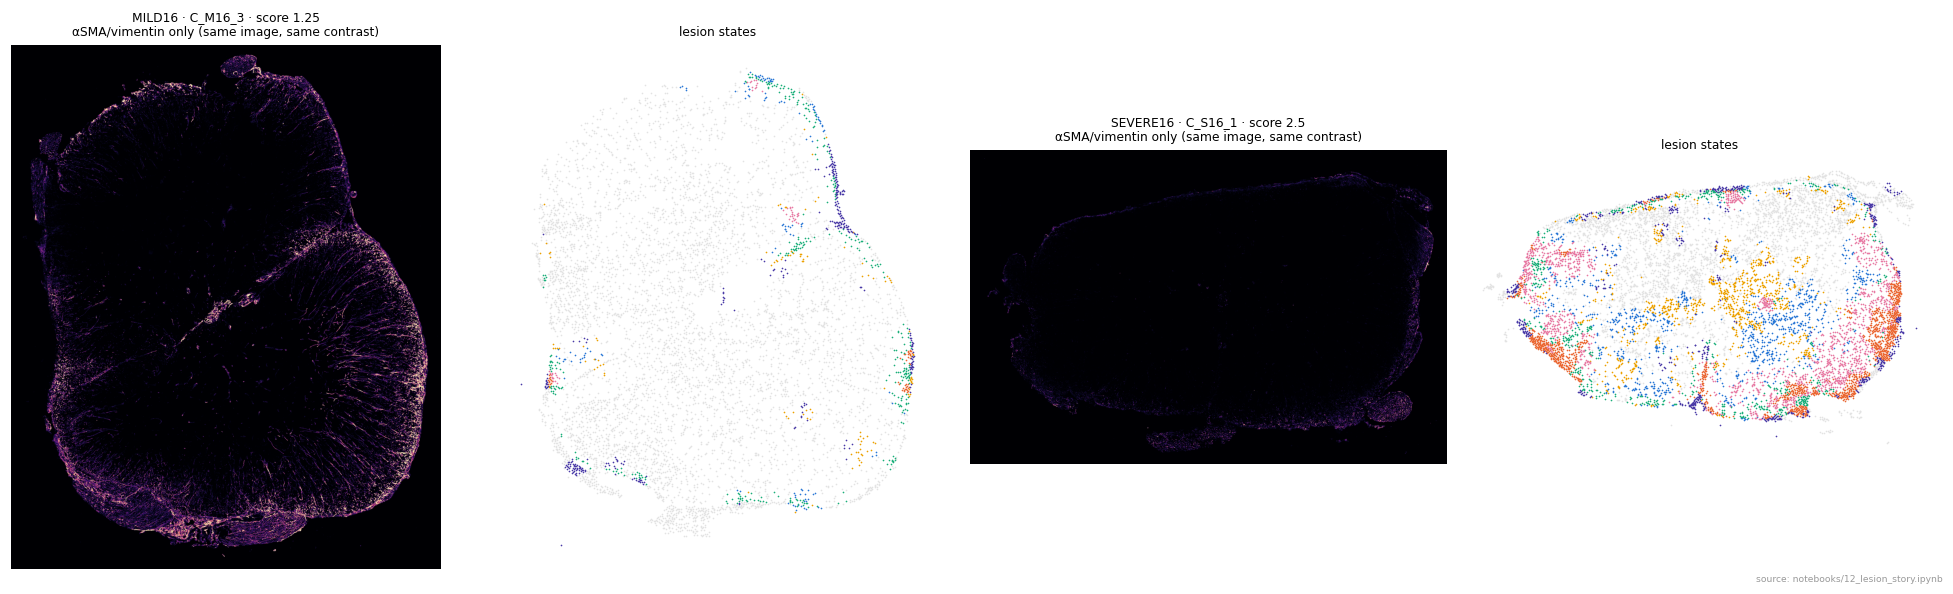

In [9]:
OVL = 2  # pyramid level 2 = 0.85 µm/px


def piece_overview(sec, piece, lv=OVL, pad_um=60):
    g = obs[obs.meta_sample_id == piece]
    f = 2 ** lv
    px = PX * f
    x0, x1 = (g.x_centroid.min() - pad_um) / px, (g.x_centroid.max() + pad_um) / px
    y0, y1 = (g.y_centroid.min() - pad_um) / px, (g.y_centroid.max() + pad_um) / px
    b = bundle(sec)
    ims = {ch: b.read_level(ch, lv) for ch in ("dapi", "smavim")}
    sl = (slice(max(int(y0), 0), int(y1)), slice(max(int(x0), 0), int(x1)))
    return {ch: im[sl] for ch, im in ims.items()}


def rgb_dapi_vim(ims, hi_d, hi_v):
    rgb = np.zeros((*ims["dapi"].shape, 3))
    rgb += np.clip(ims["dapi"] / hi_d, 0, 1)[..., None] * np.array([0.15, 0.35, 1.0])
    rgb += np.clip(ims["smavim"] / hi_v, 0, 1)[..., None] * np.array([1.0, 1.0, 1.0])
    return np.clip(rgb, 0, 1)


SEC = "run5_C2_G2_Top_0088858"
pair = obs[obs.sample_id == SEC].drop_duplicates("meta_sample_id")[["meta_sample_id", "sample_name", "stage"]]
pair = pair[pair.stage.isin(["MILD16", "SEVERE16"])].sort_values("stage")
ovs = {r.meta_sample_id: piece_overview(SEC, r.meta_sample_id) for r in pair.itertuples()}
allv = np.concatenate([o["smavim"].ravel() for o in ovs.values()])
alld = np.concatenate([o["dapi"].ravel() for o in ovs.values()])
hi_v, hi_d = np.percentile(allv, 99.7), np.percentile(alld, 99.5)
fig, axs = plt.subplots(1, 2 * len(pair), figsize=(18, 5.2))
for k, r in enumerate(pair.itertuples()):
    axs[2 * k].imshow(np.clip(ovs[r.meta_sample_id]["smavim"] / hi_v, 0, 1), cmap="magma", vmin=0, vmax=1)
    axs[2 * k].set_title(f"{r.stage} · {r.sample_name} · score {animals.loc[r.sample_name, 'score']:g}\n"
                         f"αSMA/vimentin only (same image, same contrast)", fontsize=8)
    axs[2 * k].axis("off")
    state_map(axs[2 * k + 1], r.meta_sample_id, "lesion states", s=1.2)
fig.tight_layout()
plotting.save_fig(fig, "vimentin_overview_mild_vs_severe", OUT, SRC)

> How to read the overview: the MILD16 piece shows radial vimentin fibres through the white matter and a bright
> rim; the SEVERE16 piece in the same image is dark almost everywhere, not only in its lesions. So the overview mixes
> the lesion effect with a whole-piece difference (biological or technical). The quantitative evidence is the
> within-piece contrast below (lesion vs non-lesion astrocytes of the same animal), which cancels piece-level
> brightness.

**Single lesion astrocytes.** Random lesion astrocytes (not selected by intensity) from each group, 30 µm crops,
DAPI + αSMA/vimentin. Intensities are normalised per image ((raw − local background) ÷ image scale, notebook 02)
and shown on one common scale, so animals from different images (MONOPHASIC and REMISSION1 never share an image)
are comparable. Only the vimentin channel is shown (DAPI would drown it). The number on each crop is the
cell's vimentin z.

{'MILD16': 2.59, 'SEVERE16': 0.13, 'MONOPHASIC': 5.17, 'REMISSION1': 2.16} | all lesion astrocytes: {'MILD16': 2.06, 'SEVERE16': 0.69, 'MONOPHASIC': 3.69, 'REMISSION1': 1.09}


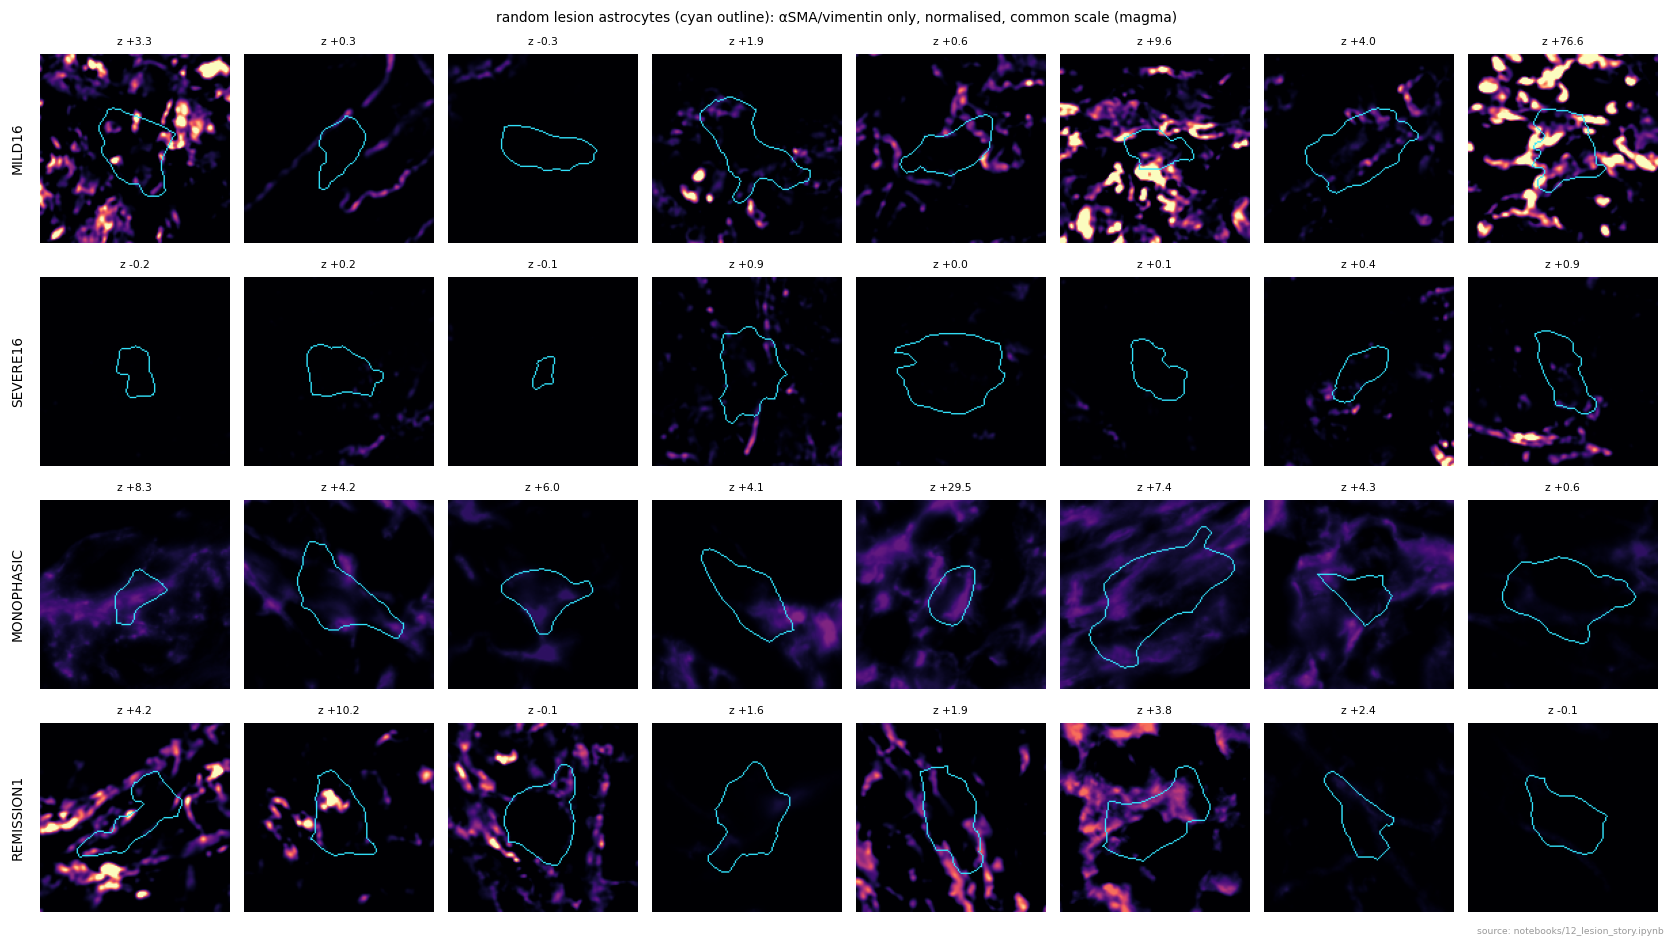

In [10]:
COLS = ["section_id", "sample_name", "Anno_L1_curated", "segmentation_method", "centroid_x_px", "centroid_y_px",
        "label", "dapi_scale", "dapi_bg_local", "smavim_scale", "smavim_bg_local", "smavim_cell_mean", "dapi_cell_mean"]
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=COLS)
fa = fa[(fa.segmentation_method == "Segmented by interior stain (18S)")].join(obs[["stage", "lesion_state"]],
                                                                               how="inner")
med = fa.smavim_cell_mean.groupby(fa.section_id).transform("median")
mad = (fa.smavim_cell_mean - med).abs().groupby(fa.section_id).transform("median") * 1.4826
fa["vim_z"] = (fa.smavim_cell_mean - med) / mad
astro = fa[(fa.Anno_L1_curated == "Astrocyte") & fa.lesion_state.str.startswith("S")]


def norm_crop(row, half_um=15):
    h = int(half_um / PX)
    y, x = int(row.centroid_y_px), int(row.centroid_x_px)
    img, cm, _ = bundle(row.section_id).read_window(y - h, x - h, 2 * h, 2 * h)
    d = (img[0] - row.dapi_bg_local) / row.dapi_scale
    v = (img[3] - row.smavim_bg_local) / row.smavim_scale
    return d, v, cm, h


GAL = ["MILD16", "SEVERE16", "MONOPHASIC", "REMISSION1"]
N = 8
picks = {g: astro[astro.stage == g].sample(N, random_state=1) for g in GAL}
crops = {g: [norm_crop(r) for r in p.itertuples()] for g, p in picks.items()}
hv = np.percentile(np.concatenate([c[1].ravel() for cc in crops.values() for c in cc]), 99.5)
hd = np.percentile(np.concatenate([c[0].ravel() for cc in crops.values() for c in cc]), 99.5)
fig, axs = plt.subplots(len(GAL), N, figsize=(N * 1.9, len(GAL) * 2.15))
for i, g in enumerate(GAL):
    for j, ((d, v, cm, h), r) in enumerate(zip(crops[g], picks[g].itertuples())):
        rgb = plt.get_cmap("magma")(np.clip(v / hv, 0, 1))[..., :3]
        rgb[find_boundaries(cm == r.label, mode="inner")] = (0.2, 0.9, 1.0)
        ax = axs[i, j]
        ax.imshow(rgb); ax.axis("off")
        ax.set_title(f"z {r.vim_z:+.1f}", fontsize=7)
    axs[i, 0].text(-0.08, 0.5, g, transform=axs[i, 0].transAxes, rotation=90, va="center", ha="right", fontsize=9)
fig.suptitle("random lesion astrocytes (cyan outline): αSMA/vimentin only, normalised, common scale (magma)",
             fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "vimentin_astrocyte_gallery", OUT, SRC)
print({g: round(float(picks[g].vim_z.median()), 2) for g in GAL}, "| all lesion astrocytes:",
      astro.groupby("stage").vim_z.median().reindex(GAL).round(2).to_dict())

**Is it piece brightness?** In the overview the SEVERE16 piece is dimmer overall, DAPI included, so a piece-level
brightness difference could leak into within-image z-scores. Two checks per animal: (i) lesion astrocytes minus
non-lesion astrocytes **of the same animal's pieces** (piece brightness cancels); (ii) the same contrast for DAPI,
which should not differ if the vimentin effect is biology rather than brightness.

In [11]:
fa["dapi_z"] = fa.dapi_cell_mean.groupby(fa.section_id).transform(
    lambda v: (v - v.median()) / ((v - v.median()).abs().median() * 1.4826))
ast_all = fa[fa.Anno_L1_curated == "Astrocyte"]
les_a = ast_all.lesion_state.str.startswith("S")
non_a = ast_all.lesion_state == "no lesion"
chk = pd.DataFrame({
    "vimentin: lesion − non-lesion astrocytes": ast_all[les_a].groupby("sample_name").vim_z.median()
    - ast_all[non_a].groupby("sample_name").vim_z.median(),
    "DAPI: lesion − non-lesion astrocytes": ast_all[les_a].groupby("sample_name").dapi_z.median()
    - ast_all[non_a].groupby("sample_name").dapi_z.median(),
    "non-lesion astrocyte vimentin (piece level)": ast_all[non_a].groupby("sample_name").vim_z.median(),
    "non-lesion DAPI (piece level)": fa[fa.lesion_state == "no lesion"].groupby("sample_name").dapi_z.median(),
}).join(animals[["stage", "arm"]])
grp = {"MILD16": "MILD16", "SEVERE16": "SEVERE16", "MILD30": "MILD30", "SEVERE30": "SEVERE30",
       "MONOPHASIC": "MONOPHASIC", "REMISSION1": "REMISSION1"}
t = chk[chk.stage.isin(grp)].groupby("stage")[chk.columns[:4]].median().reindex(list(grp))
t.loc["chronic PEAK1"] = chk[(chk.stage == "PEAK1") & (chk.arm == "chronic")][chk.columns[:4]].median()
t.loc["RR PEAK1"] = chk[(chk.stage == "PEAK1") & (chk.arm == "RR")][chk.columns[:4]].median()
chk.to_csv(OUT / "vimentin_piece_brightness_check.csv")
t.round(2)

/tmp/ipykernel_35352/1839987769.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "vimentin: lesion − non-lesion astrocytes": ast_all[les_a].groupby("sample_name").vim_z.median()
/tmp/ipykernel_35352/1839987769.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  - ast_all[non_a].groupby("sample_name").vim_z.median(),
/tmp/ipykernel_35352/1839987769.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "DAPI: lesion − non

,vimentin: lesion − non-lesion astrocytes,DAPI: lesion − non-lesion astrocytes,non-lesion astrocyte vimentin (piece level),non-lesion DAPI (piece level)
stage,,,,
MILD16,2.07,-0.19,0.00,-0.01
SEVERE16,0.97,-0.01,-0.01,-0.20
MILD30,3.03,-0.10,-0.12,-0.10
SEVERE30,1.94,0.10,-0.05,0.04
MONOPHASIC,4.57,0.08,-0.32,-0.15
REMISSION1,1.26,0.08,-0.20,-0.28
chronic PEAK1,1.08,0.03,0.19,-0.25
RR PEAK1,0.58,0.06,-0.36,-0.26


> **Check.** The within-piece vimentin contrast (lesion minus non-lesion astrocytes of the same animal) keeps the
> direction of every comparison, while the DAPI contrast stays near zero. Whatever piece-level brightness exists, the
> lesion-specific vimentin difference is not explained by it (numbers in the table above).

> **Finding — vimentin marks contained lesions.** Lesion astrocyte vimentin: MILD16 vs SEVERE16 2.3 vs 0.7 (same
> images), MILD30 vs SEVERE30 4.4 vs 2.0, MONOPHASIC vs REMISSION1 3.3 vs 1.1, chronic vs RR first peak 2.6 vs 0.2
> (p = 0.04), and within the glial state from peak to recovery 0.16 → 1.14. Among the 13 chronic-late animals, more
> vimentin goes with a lower score (ρ = −0.80, the strongest correlate of severity). Mild and resolving lesions are wrapped by vimentin-bright reactive
> astrocytes; severe and active ones are not (yet). The transcriptome can't show this: *Vim* is not on the panel and
> reactive-astrocyte RNA is similar between groups (notebook 11). Caveats: 3–19 animals per group, no single test
> survives strict correction, and the channel also contains αSMA (vascular smooth muscle).

## 5. Chronic severity = lesions that stayed active
Each chronic-late animal (d27–50): clinical score against how active its lesions still are, and against lesion
vimentin.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/chronic_severity_scatter.png')

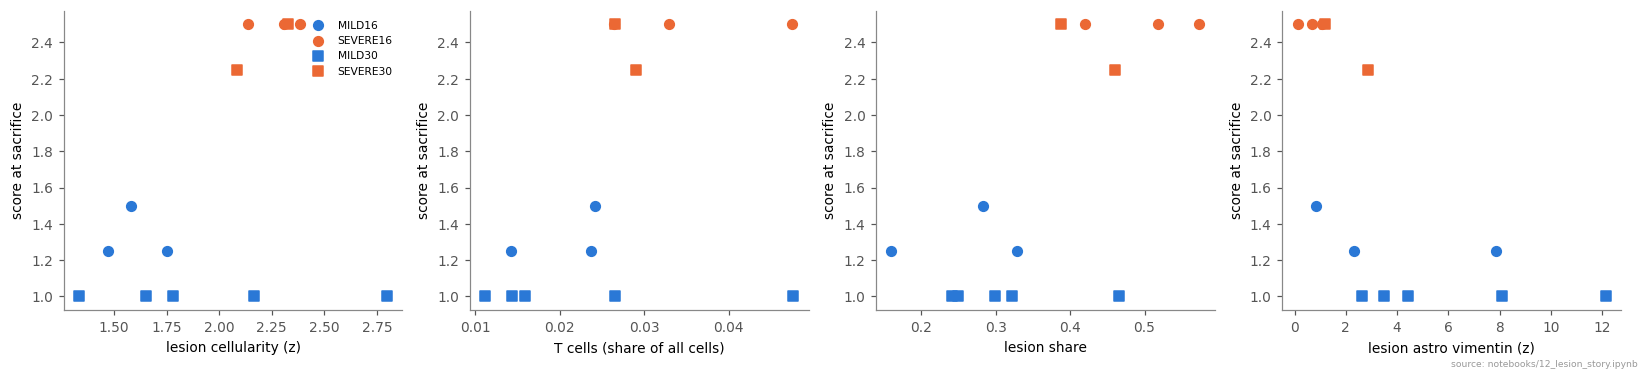

In [12]:
cl = animals[animals.group == "chronic late"]
fig, axs = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, c, lab in zip(axs, ["lesion axis: cellularity", "frac T cell", "lesion share", vim],
                      ["lesion cellularity (z)", "T cells (share of all cells)", "lesion share", "lesion astro vimentin (z)"]):
    for stg, mk in [("MILD16", "o"), ("SEVERE16", "o"), ("MILD30", "s"), ("SEVERE30", "s")]:
        d = cl[cl.stage == stg]
        ax.scatter(d[c], d.score, marker=mk, s=40, color=COL[0] if "MILD" in stg else COL[1], label=stg)
    ax.set(xlabel=lab, ylabel="score at sacrifice")
axs[0].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "chronic_severity_scatter", OUT, SRC)

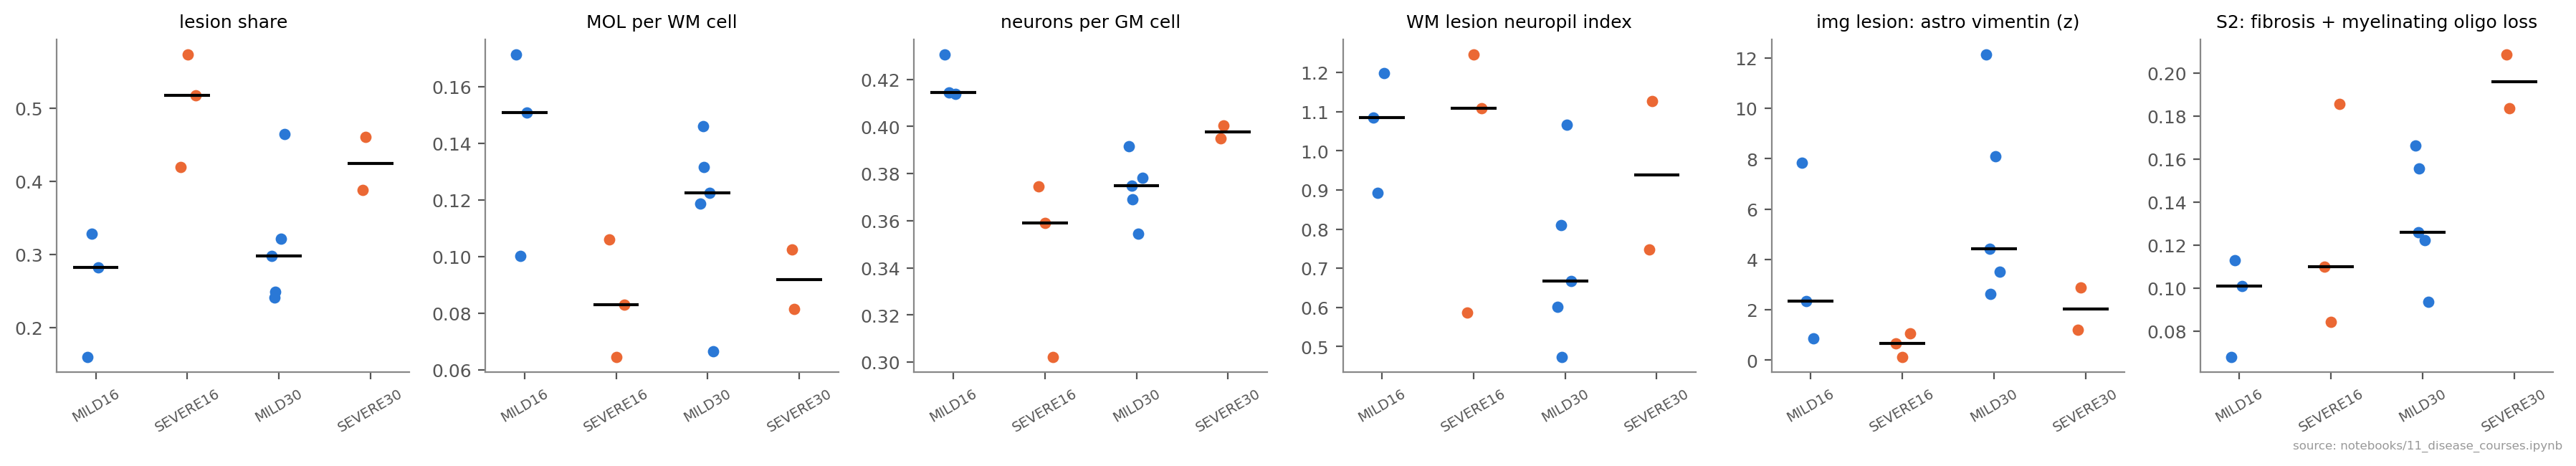

In [13]:
show("11_disease_courses/chronic_mild_vs_severe.png")

> **Finding — severity: lesions that stayed active and never got the vimentin response.** Severe chronic animals
> still carry more lesion, more active monocyte-derived states (S1/S4), more T cells and denser infiltrates at
> d28–41, and have lost more myelinating oligodendrocytes (0.08 vs 0.15 per WM cell); surrounding neuropil is not
> reduced more. Across all 13 chronic-late animals, the **strongest correlate of the score is low lesion astrocyte
> vimentin (ρ = −0.80)**, then lesion share (0.58), T cells (0.47) and cellularity (0.38). In run 5 alone (n = 8, no
> MILD30) the inflammation correlations are higher (0.77–0.89) and vimentin −0.66. So the severe course is lesions that
> did not resolve, more than irreversible loss. MILD30 is the only run-1 group (MILD30 names were matched to the
> score sheet by sacrifice day and sex, `scripts/clinical_metrics.py`).

## 6. Relapse and B cells
B cells per 1000 cells and the share sitting in aggregates (≥ 5 B cells among their 15 nearest cells), per animal
along both courses:

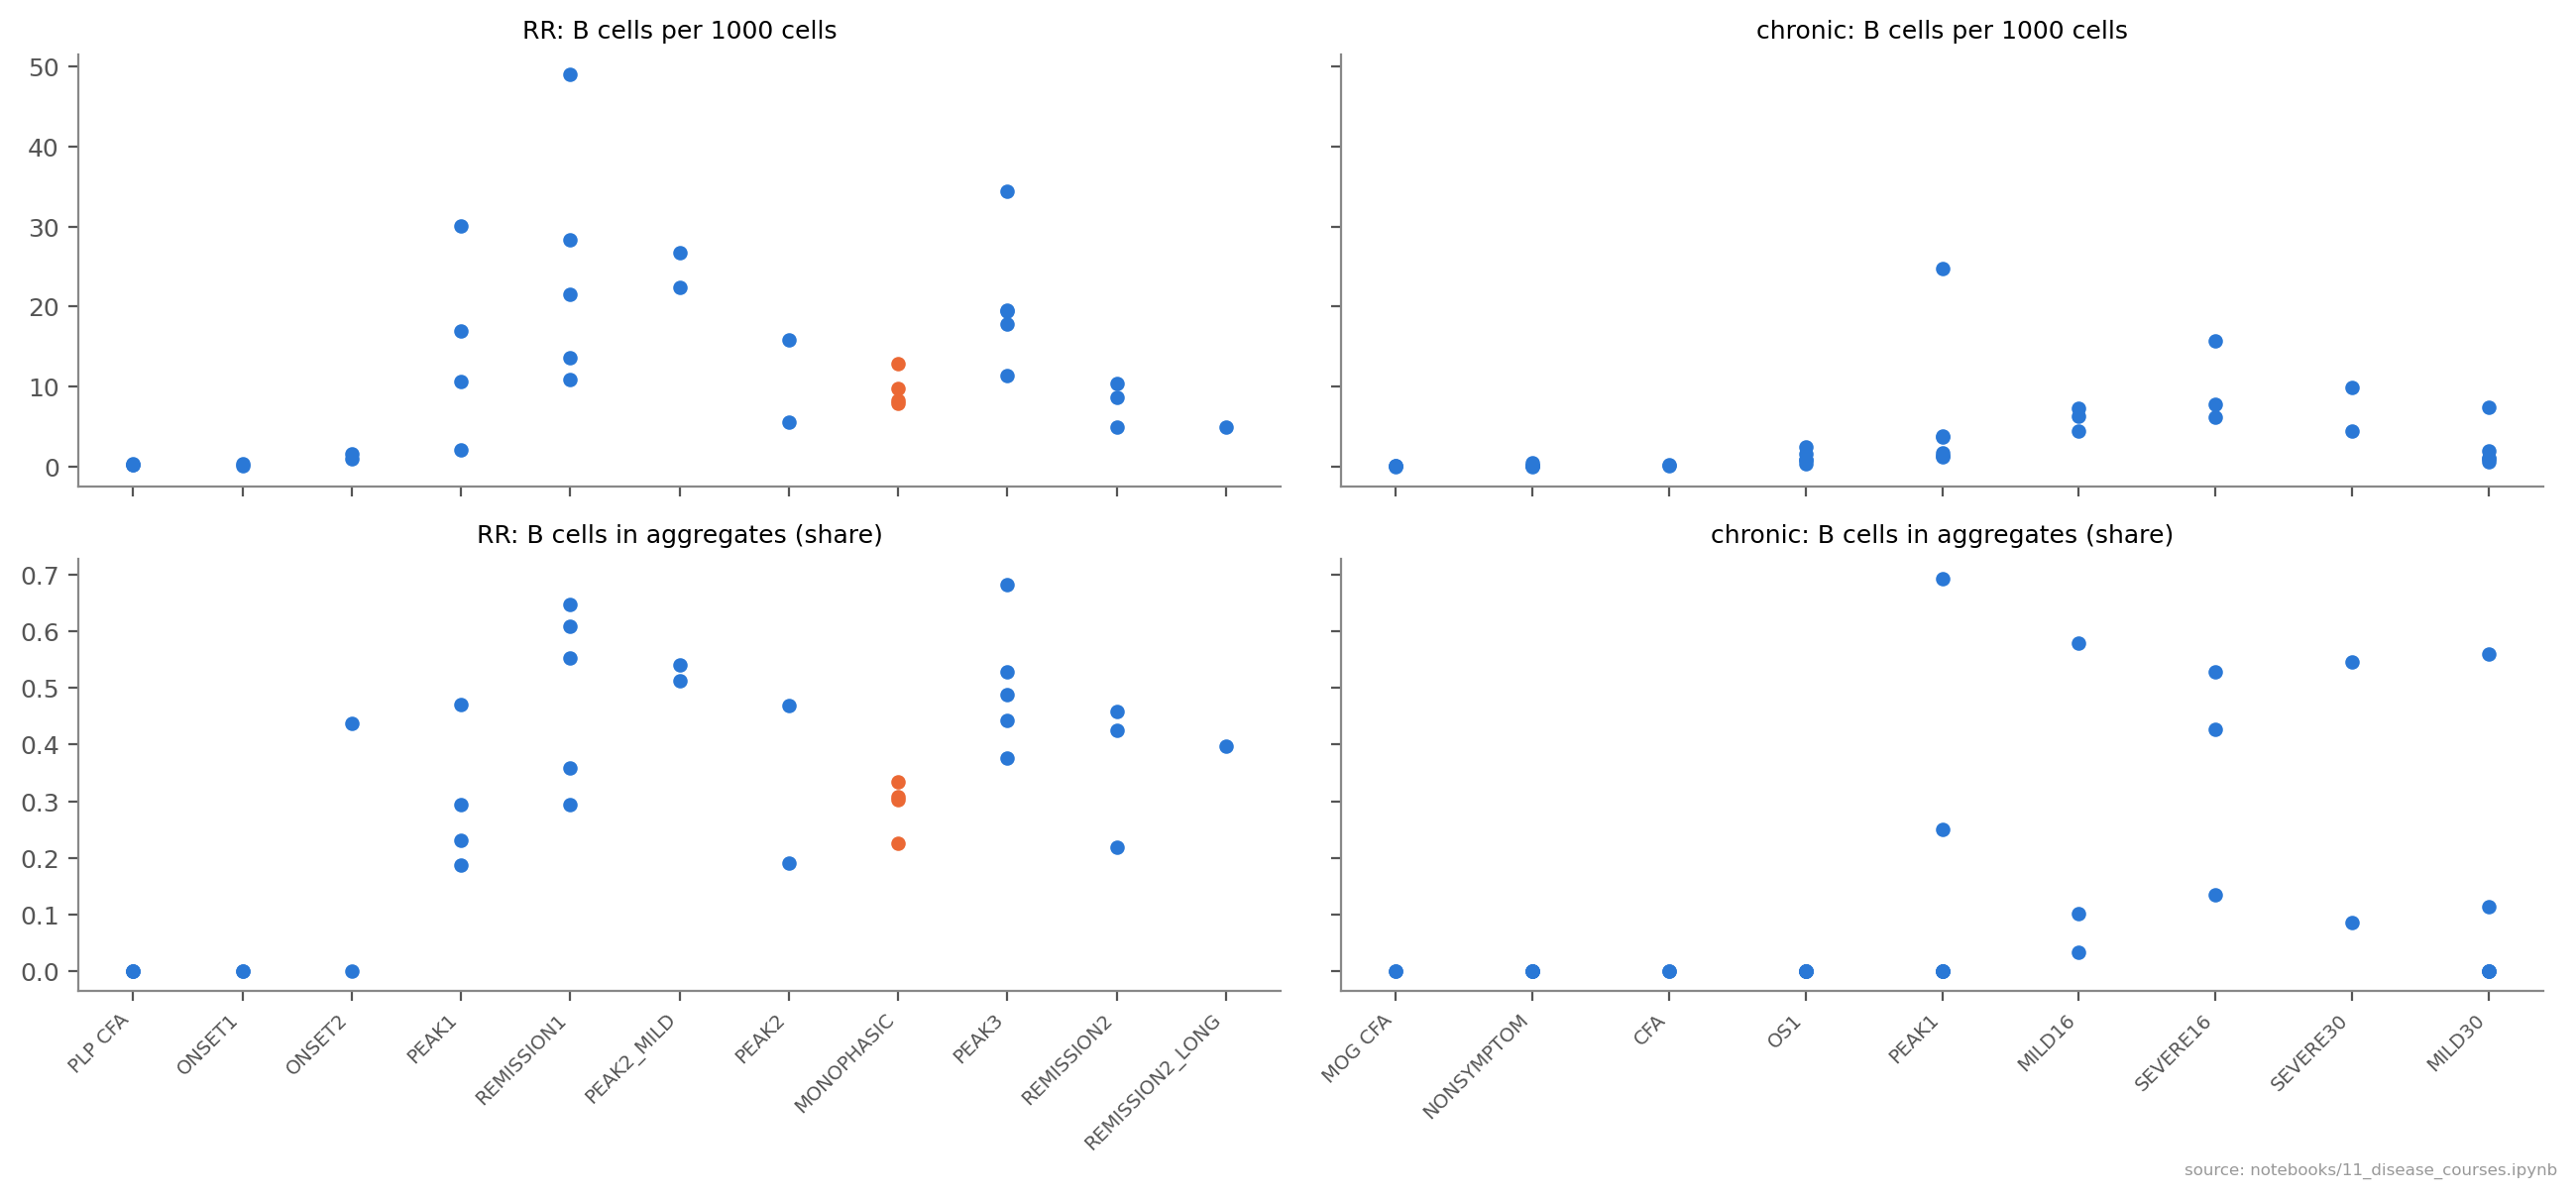

In [14]:
show("11_disease_courses/b_cells_by_stage.png")

Where they are: a representative REMISSION1 animal (relapse-prone window) and a representative MONOPHASIC animal
(never relapsed). Grey = all cells, light blue = meninges, red = B cells, dark red = B cells in aggregates.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/b_cell_maps.png')

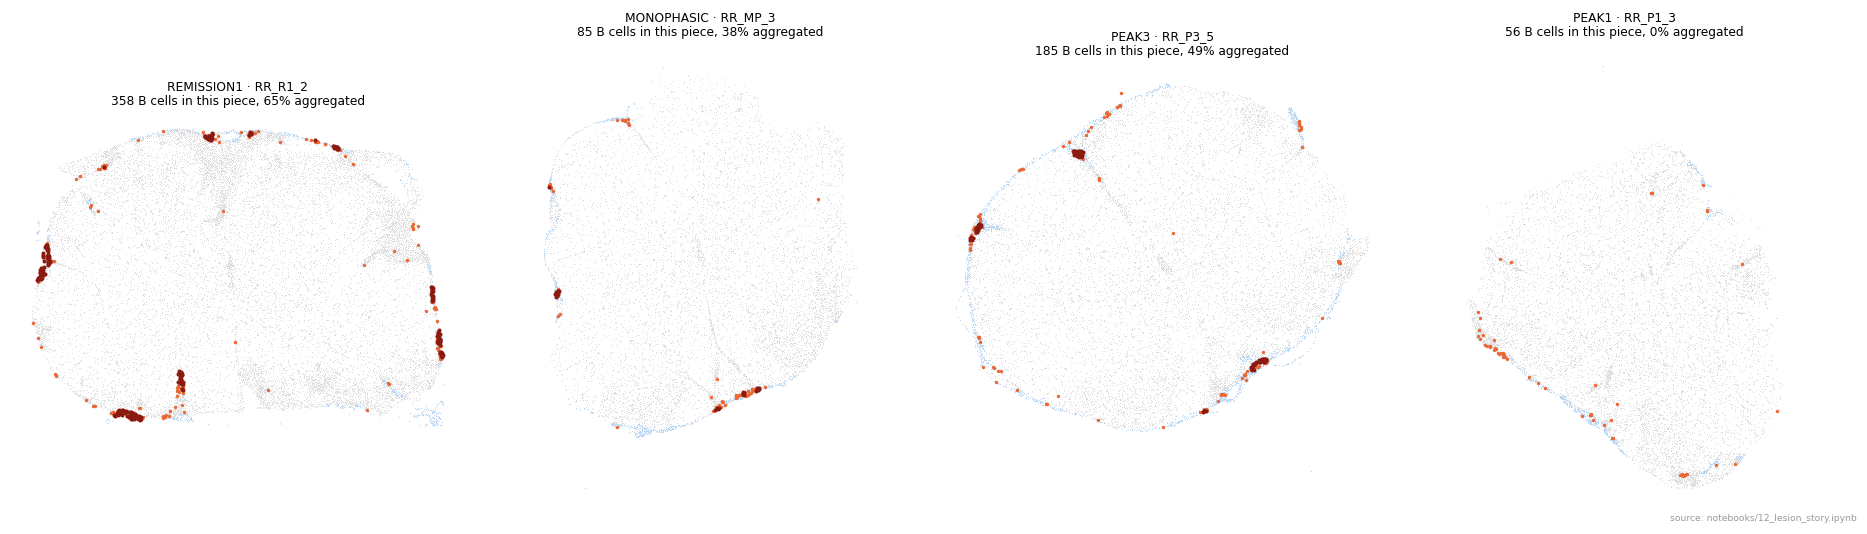

In [15]:
bmask = obs.ctype == "B cell"
agg = pd.Series(False, index=obs.index)
for _, g in obs.groupby("meta_sample_id", observed=True):
    b = g[g.ctype == "B cell"]
    if len(b) < 5:
        continue
    _, nn = cKDTree(g[["x_centroid", "y_centroid"]].to_numpy()).query(b[["x_centroid", "y_centroid"]].to_numpy(), k=16)
    agg[b.index] = (g.ctype == "B cell").to_numpy()[nn[:, 1:]].sum(1) >= 5
obs["b_agg"] = agg


def bcell_map(ax, piece, title):
    g = obs[obs.meta_sample_id == piece]
    ax.scatter(g.x_centroid, -g.y_centroid, s=0.4, color="#dddddd", rasterized=True, lw=0)
    m = g.region_class == "meninges"
    ax.scatter(g.x_centroid[m], -g.y_centroid[m], s=0.6, color="#b9d7f5", rasterized=True, lw=0)
    b = g.ctype == "B cell"
    ax.scatter(g.x_centroid[b & ~g.b_agg], -g.y_centroid[b & ~g.b_agg], s=5, color="#eb6834", lw=0)
    ax.scatter(g.x_centroid[b & g.b_agg], -g.y_centroid[b & g.b_agg], s=7, color="#8b1a10", lw=0)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=8)


bc = animals["frac B cell"]
reps = {}
for stg in ["REMISSION1", "MONOPHASIC", "PEAK3", "PEAK1"]:
    d = bc[(animals.stage == stg) & (animals.arm == "RR")].dropna()
    reps[stg] = (d - d.median()).abs().idxmin()
fig, axs = plt.subplots(1, 4, figsize=(17, 4.8))
for ax, (stg, an) in zip(axs, reps.items()):
    pc = piece_of(an)
    nb = (obs.meta_sample_id == pc) & bmask
    bcell_map(ax, pc, f"{stg} · {an}\n{int(nb.sum())} B cells in this piece, {obs.loc[nb, 'b_agg'].mean():.0%} aggregated")
fig.tight_layout()
plotting.save_fig(fig, "b_cell_maps", OUT, SRC)

**A B-cell aggregate under the microscope** (the largest aggregate in REMISSION1 tissue): each stain on its own,
B cells outlined in cyan.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/b_cell_aggregate_microscopy.png')

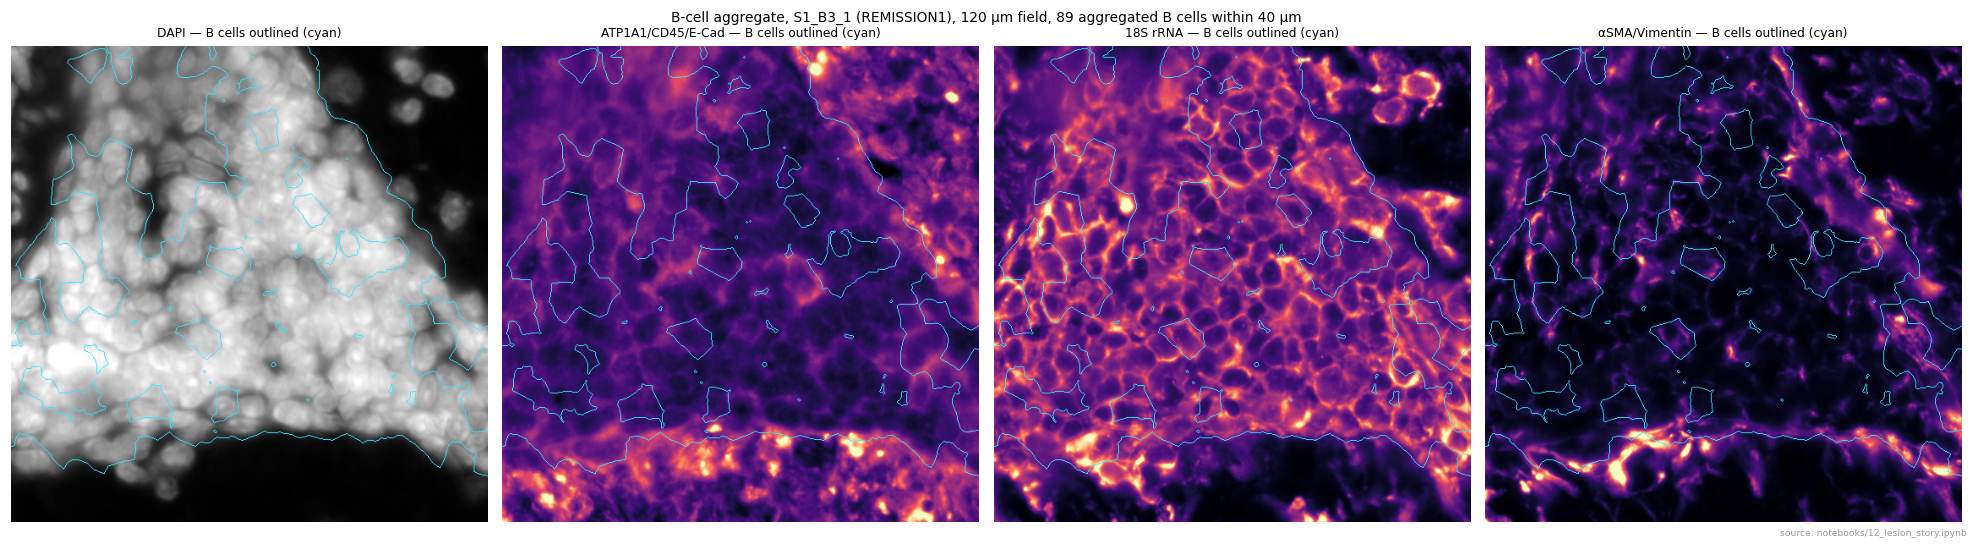

In [16]:
bfa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                      columns=["section_id", "centroid_x_px", "centroid_y_px", "label"]).join(
    obs[["stage", "ctype", "b_agg", "meta_sample_id", "x_centroid", "y_centroid"]], how="inner")
cand = bfa[(bfa.stage == "REMISSION1") & bfa.b_agg]
best = None
for pc, g in cand.groupby("meta_sample_id", observed=True):
    t = cKDTree(g[["x_centroid", "y_centroid"]].to_numpy())
    n = np.array([len(x) for x in t.query_ball_point(g[["x_centroid", "y_centroid"]].to_numpy(), 40)])
    if best is None or n.max() > best[0]:
        best = (n.max(), g.iloc[int(n.argmax())])
row = best[1]
h = int(60 / PX)
y, x = int(row.centroid_y_px), int(row.centroid_x_px)
img, cm, _ = bundle(row.section_id).read_window(y - h, x - h, 2 * h, 2 * h)
blabels = bfa[(bfa.section_id == row.section_id) & (bfa.ctype == "B cell")].label.to_numpy()
bnd = find_boundaries(np.isin(cm, blabels), mode="inner")
fig, axs = plt.subplots(1, 4, figsize=(18, 4.9))
for ax, i, cmap in zip(axs, range(4), ["gray", "magma", "magma", "magma"]):
    rgb = plt.get_cmap(cmap)(np.clip(img[i] / np.percentile(img[i], 99.7), 0, 1))[..., :3]
    rgb[bnd] = (0.2, 0.9, 1.0)
    ax.imshow(rgb); ax.axis("off")
    ax.set_title(f"{plotting.CHANNEL_LABELS[data.CHANNELS[i]]} — B cells outlined (cyan)", fontsize=8)
fig.suptitle(f"B-cell aggregate, {row.meta_sample_id} (REMISSION1), 120 µm field, {best[0]} aggregated B cells within 40 µm",
             fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "b_cell_aggregate_microscopy", OUT, SRC)

> **Finding — B cells accumulate after the first attack in relapsing–remitting EAE.** B cells per 1000 cells: RR
> PEAK1 14 → REMISSION1 22 → PEAK2_MILD 25 / PEAK3 19; the aggregated share rises from 0.26 to 0.55 and they move
> into the meninges (16 % at PEAK1 → 58–90 % later). Never-relapsing MONOPHASIC animals have fewer than REMISSION1
> animals (9 vs 22, p = 0.03; aggregated 0.31 vs 0.55), recovered further from the first attack (lowest score 0.25 vs
> 0.75) and show more lesion vimentin (section 4). The chronic arm has few B cells throughout (≤ 8). A candidate
> picture: relapse-prone animals build meningeal B-cell aggregates and contain their lesions less. Cross-sectional,
> 4–5 animals per group; REMISSION1 animals' future is unknown. Notebook 14 asks whether relapse lesions start next to
> old ones.

## 7. Chronic vs relapsing–remitting at the same peak
Both PEAK1 (d13–18, score ~3); different antigens/strains and runs, so differences are descriptive.

In [17]:
c3 = pd.read_csv(RES / "11_disease_courses" / "chronic_vs_rr_peak1.csv", index_col=0)
c3 = c3.drop(columns=[c for c in c3 if c.startswith("n ")]).sort_values("p").head(10)
c3.round(3)

,chronic PEAK1,RR PEAK1,diff,p
measure,,,,
S4: monocyte-derived myeloid + oligo disease state,0.169,0.256,0.088,0.010
lesion axis: lipid-assoc. myeloid,9.072,5.405,-3.667,0.010
frac CAM,0.015,0.009,-0.006,0.019
img lesion: astro vimentin (z),2.590,0.182,-2.408,0.038
frac other,0.013,0.016,0.003,0.038
img non-lesion: tissue vimentin (z),-0.082,-0.188,-0.106,0.038
img non-lesion: astro vimentin (z),0.582,-0.433,-1.016,0.048
lesion share,0.871,0.933,0.062,0.114
S2: fibrosis + myelinating oligo loss,0.027,0.011,-0.017,0.114


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/12_lesion_story/peak1_chronic_vs_rr_maps.png')

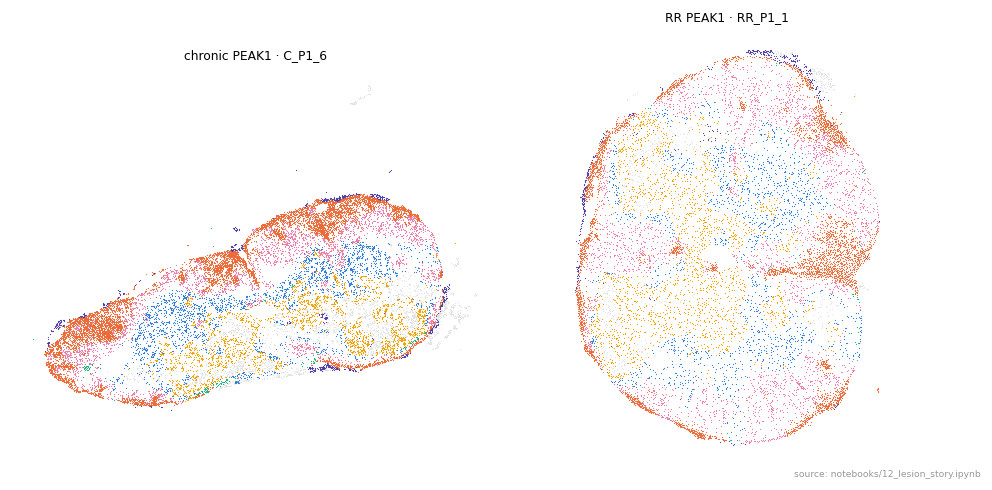

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4.4))
for ax, arm in zip(axs, ["chronic", "RR"]):
    d = animals[(animals.stage == "PEAK1") & (animals.arm == arm)]["lesion share"].dropna()
    an = (d - d.median()).abs().idxmin()
    state_map(ax, piece_of(an), f"{arm} PEAK1 · {an}")
fig.tight_layout()
plotting.save_fig(fig, "peak1_chronic_vs_rr_maps", OUT, SRC)

> RR first-peak lesions are more monocyte-derived with oligodendrocyte damage (S4 0.26 vs 0.17 of tissue, p = 0.01)
> and less lipid-laden; RR animals have more B cells (14 vs 3 per 1000) and lose more weight (22 vs 14 %); chronic
> lesions already show more astrocyte vimentin (2.6 vs 0.2).

## 8. Damage memory: neuropil returns, vimentin builds
The same lesion state compared between peak (19 animals) and recovery (13 animals), all five runs:

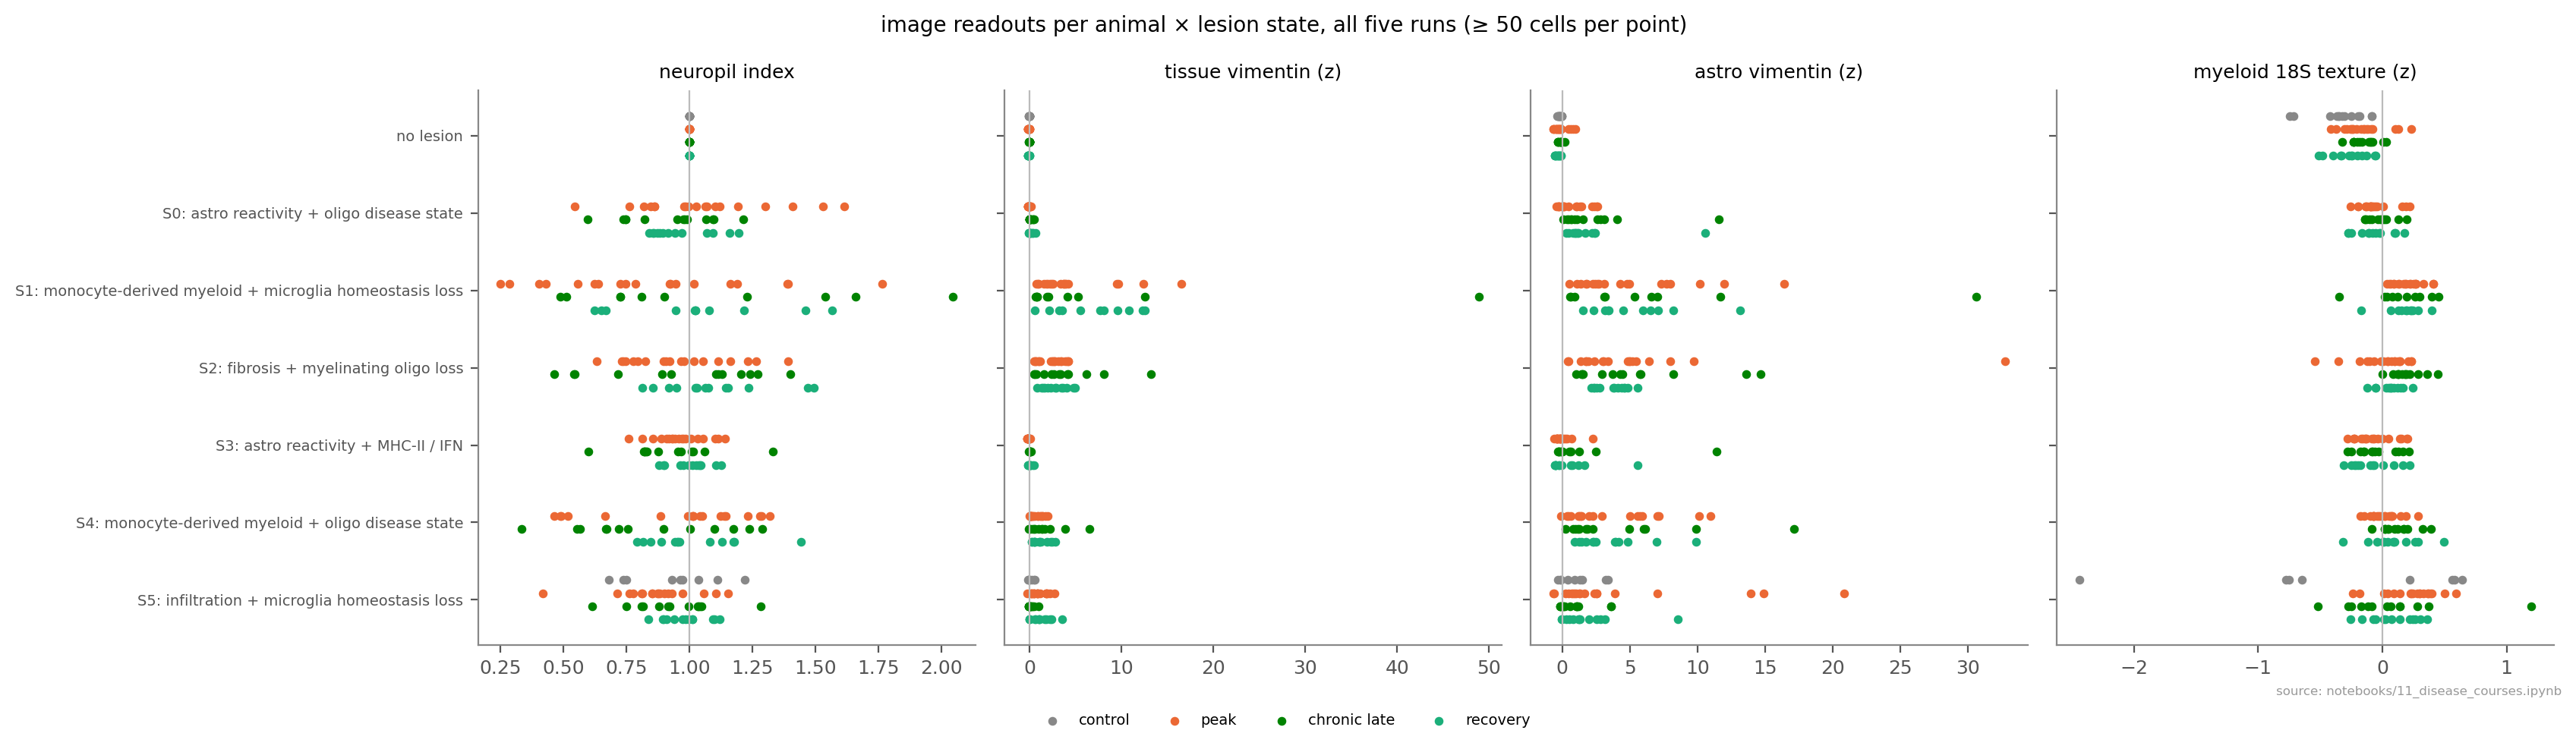

In [19]:
show("11_disease_courses/image_readouts_by_state_all_runs.png")

> Within the same lesion state, the ATP1A1 neuropil around cells trends back towards normal from peak to recovery
> (active S1 0.79 → 1.03; lymphocytic S5 0.88 → 0.99, p = 0.02) while vimentin rises (glial S0/S3 tissue vimentin
> p = 0.009/0.005; best q = 0.13). Lesions that persist into recovery look repaired in neuropil but scarred in
> vimentin: a tissue memory the stains show and the lesion label doesn't.

## 9. Caveats and next
- Groups are small (3–19 animals); evidence is consistency across independent contrasts, not single p values.
- Arms differ in antigen, likely strain, and run; MILD30 is run 1 only; MONOPHASIC and REMISSION1 never share an
  image (within-image z and normalised display used).
- Lesion calls and states are transcriptome-defined (control-referenced); image readouts are independent of them.
- The αSMA/vimentin channel pools two proteins; vascular αSMA is a minority in astrocytes (notebook 07).
- Neuropil index reference differs from notebook 06 (lesion index > 1 in some chronic groups), checked in notebook 13.

**Next:** notebook 13 replicates the earlier image findings on runs 1–3; notebook 14 asks whether relapse lesions
start next to old ones.